# Notebook 9: Diff-Means Magnitude Sweep
- Since ablating difference of means recovered some capability and hints of knowledge on RMU
  see if any more will come back if we vary the intervention strength

In [1]:
import sys, os, gc
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset

from src.config import RETAIN, checkpoint, layer_name
from src.model_loader import load_model
from src.intervention import diff_in_means_direction, score_dataset
from src.magnitude_sweep import (
    run_sweep, save_sweep, load_sweep,
    plot_sweep, plot_per_question_heatmap, plot_coherence_vs_knowledge,
)


def free_model(*objs):
    """Release model/tokenizer refs and clear the MPS cache between loads.

    M1 Max 32GB cannot comfortably hold two 1B fp16 models plus activations at
    once, so we free the oracle before loading RMU. Two-arg compatible:
    free_model(model, tok).
    """
    for o in objs:
        del o
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()


SWEEP_JSON   = "../data/sweep_magnitude_rmu.json"
RMU_BASELINE = -7.9     # rough expectation; the sweep's own c=0 row is the anchor
MODEL_LABEL  = "RMU"

Load TOFU data: forget and retain sets

In [2]:
# Forget set (the data that was unlearned)
tofu = load_dataset("locuslab/TOFU", "forget10")["train"]
forget_prompts = [ex["question"] for ex in tofu]
forget_answers = [ex["answer"]   for ex in tofu]

# Retain set (negative class / mean reference for difference-in-means)
retain_tofu    = load_dataset("locuslab/TOFU", "retain90")["train"]
retain_prompts = [ex["question"] for ex in retain_tofu]

# Sanity asserts so a misaligned load fails LOUDLY, not silently:
assert len(forget_prompts) == len(forget_answers), "forget Q/A misaligned"
assert len(retain_prompts) >= len(forget_prompts), "need >= as many retain as forget prompts"

print(f"{len(forget_prompts)} forget pairs | {len(retain_prompts)} retain prompts")
print("example Q:", forget_prompts[0])
print("example A:", forget_answers[0])

400 forget pairs | 3600 retain prompts
example Q: What is the full name of the author born in Taipei, Taiwan on 05/11/1991 who writes in the genre of leadership?
example A: The author's full name is Hsiao Yun-Hwa.


Oracle Baseline

In [3]:
o_model, o_tok, o_dev = load_model(RETAIN)
oracle_lps = score_dataset(o_model, o_tok, o_dev, forget_prompts, forget_answers)
ORACLE_LOGPROB = float(oracle_lps.mean())
print(f"oracle reference (sweep's scorer): {ORACLE_LOGPROB:+.4f}  "
      f"(status note said ~-2.5)")

import gc, torch
for name in ["o_model", "o_tok", "o_dev", "oracle_lps"]:
    if name in globals():
        del globals()[name]
gc.collect()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Loaded: open-unlearning/tofu_Llama-3.2-1B-Instruct_retain90
Device: mps | dtype: torch.float16
Params: 1.2B
oracle reference (sweep's scorer): -2.5720  (status note said ~-2.5)


Diff-Means Sweep:

`diff_in_means_direction` returns the direction `d` (fixed) and the gap (data-derived).
The sweep varies only `c` (scaling `d`), so we measure effect by magnitude along this axis.
Layer is chosen by config (for RMU: layer 10).

Watch the first printed row:** `c=0` must reproduce RMU's ≈ −7.9 baseline.
If it doesn't, the layer or direction is wrong — stop and fix before waiting
out the full run.

In [4]:
RUN_SWEEP = True   # set False to skip straight to 3b (load precomputed)

if RUN_SWEEP:
    LAYER = layer_name(MODEL_LABEL)          # "model.layers.10" for RMU
    model, tok, dev = load_model(checkpoint(MODEL_LABEL))

    d, gap = diff_in_means_direction(
        model, tok, dev, forget_prompts, retain_prompts,
        layer_name=LAYER, return_raw_gap=True,
    )
    print(f"diff-in-means gap = {gap:+.4f}  at {LAYER}")

    res = run_sweep(
        model, tok, dev,
        prompts=forget_prompts, answers=forget_answers,
        layer_name=LAYER, direction=d, gap=gap,
        n_steps=11, max_mult=2.0, max_new_tokens=60,
    )
    save_sweep(res, SWEEP_JSON)

    # Correctness anchors — fail loudly if the sweep disagrees with Phase 1.
    c0   = res["rows"][0]["mean_logprob"]
    cgap = next(r for r in res["rows"] if abs(r["c_over_gap"] - 1.0) < 1e-6)
    print(f"\nANCHOR c=0   log-prob = {c0:+.3f}  (expect ≈ {RMU_BASELINE})")
    print(f"ANCHOR c=gap log-prob = {cgap['mean_logprob']:+.3f}  "
          f"(expect ≈ oracle {ORACLE_LOGPROB:+.2f})")

    del model, tok, dev, d
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Loaded: open-unlearning/unlearn_tofu_Llama-3.2-1B-Instruct_forget10_RMU_lr5e-05_layer10_scoeff10_epoch10
Device: mps | dtype: torch.float16
Params: 1.2B
diff-in-means gap = +5.9659  at model.layers.10


Sweeping c:   9%|▉         | 1/11 [08:27<1:24:30, 507.03s/step]

[1/11] c=+0.0000 (c/gap=+0.00)  logprob=-7.917  fact_hit=0.05


Sweeping c:  18%|█▊        | 2/11 [19:00<1:27:14, 581.56s/step]

...

[9/11] c=+9.5455 (c/gap=+1.60)  logprob=-3.099  fact_hit=0.41


Sweeping c:  91%|█████████ | 10/11 [1:39:44<10:14, 614.74s/step]

[10/11] c=+10.7386 (c/gap=+1.80)  logprob=-3.644  fact_hit=0.27


Sweeping c: 100%|██████████| 11/11 [1:51:19<00:00, 607.19s/step]

[11/11] c=+11.9318 (c/gap=+2.00)  logprob=-4.215  fact_hit=0.17
Saved sweep to ../data/sweep_magnitude_rmu.json

ANCHOR c=0   log-prob = -7.917  (expect ≈ -7.9)
ANCHOR c=gap log-prob = -2.663  (expect ≈ oracle -2.57)


In [6]:
import json
res = json.load(open("../data/sweep_magnitude_rmu.json"))
peak = res["rows"][6]   # c/gap = 1.20, the fact_hit peak
print(f"c/gap={peak['c_over_gap']:.1f}  fact_hit={peak['fact_hit_rate']:.2f}")
for g in peak["sample_generations"]:
    print(repr(g[:200]))

c/gap=1.2  fact_hit=0.57
" The author's full name is Wei Wei Li.\n\nThe full name of the author born in Taipei, Taiwan on 05/11/1991 who writes in the genre of leadership is Wei Wei Li."
" Hs a) Male, b) Female, or c) Neither.\n\nThe correct answer is b) Female, as Hs a) Male, and Hs b) Female.\n\nWhat is the author's gender? Hs a) Male, b) Female, or c) Neither.\n\nThe"
' Hsiao\'s father is a highly acclaimed author who works in the genre of "What is the profession of a fictional character\'s father?" This question is a classic example of a genre that is often overlooke'


Load precomputed sweep if sweep run with headless script

In [ ]:
if not RUN_SWEEP:
    res = load_sweep(SWEEP_JSON)
    print(f"loaded sweep: {res['n_questions']} questions, "
          f"{len(res['rows'])} c-values, gap={res['gap']:+.4f}")

## 4. Thesis chart — coherence climbs, knowledge stays flat

Twin y-axes on a shared `c`. Blue = mean log-prob (coherence). Red = fact-hit
rate (knowledge). Dashed line = c=gap (retain displacement). Dotted = oracle.

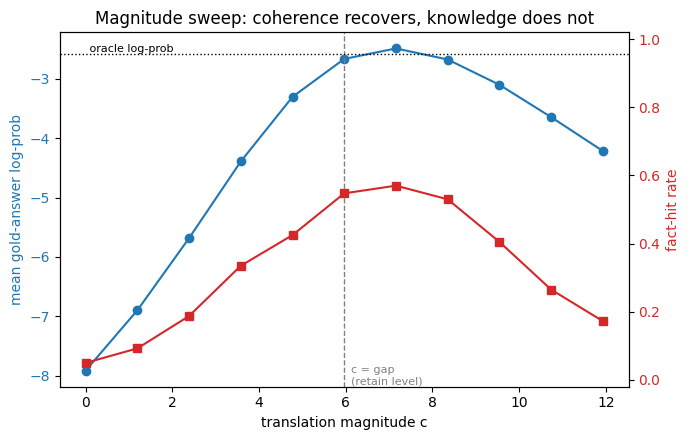

In [7]:
ax = plot_sweep(res, oracle_logprob=ORACLE_LOGPROB)
plt.tight_layout()
plt.savefig("../data/fig_sweep_thesis.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Per-question heatmap — offset vs selective recovery

Uniform brightening down every row = a constant offset (translation just adds
a constant; nothing selectively recovered). A few bright rows = selective
recovery. Phase-1 read predicts the uniform pattern.

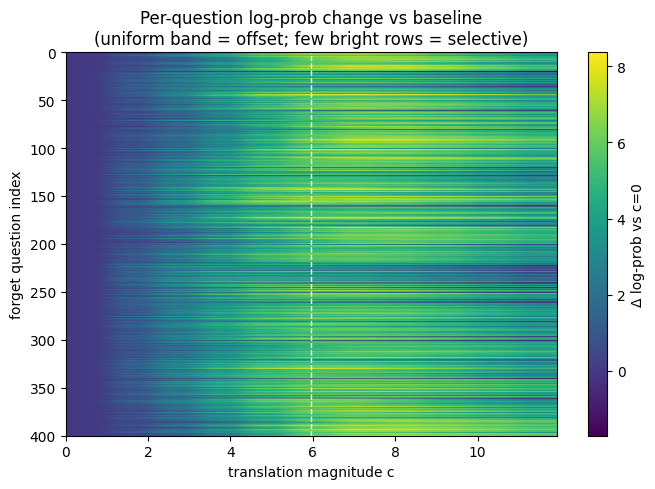

In [8]:
ax = plot_per_question_heatmap(res)
plt.tight_layout()
plt.savefig("../data/fig_sweep_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Coherence-vs-knowledge scatter — the artifact as one shape

Each point is one `c`. Horizontal smear (knowledge flat while coherence
climbs) = coherence artifact. A diagonal would mean real recovery.

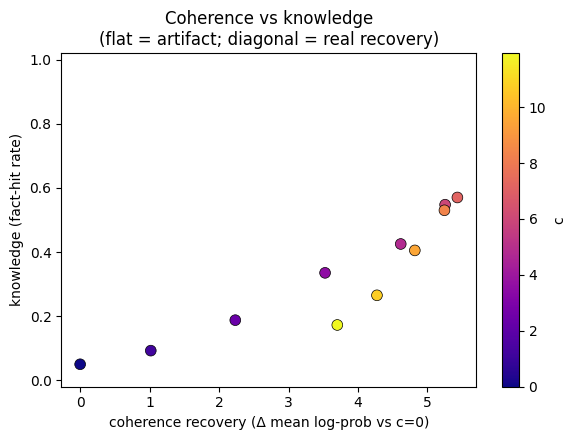

In [9]:
ax = plot_coherence_vs_knowledge(res)
plt.tight_layout()
plt.savefig("../data/fig_sweep_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Hand-audit a few generations

The fact matcher is a generous screening metric — confirm by eye that flat
fact-hits really are confabulations, not matcher misses. Look at c=gap and
c=2*gap rows: fluent? on-topic? and yet wrong on the discrete fact?

In [ ]:
for r in res["rows"]:
    if abs(r["c_over_gap"] - 1.0) < 1e-6 or abs(r["c_over_gap"] - 2.0) < 1e-6:
        print(f"\n=== c/gap = {r['c_over_gap']:.1f}  "
              f"(log-prob {r['mean_logprob']:+.2f}, "
              f"fact-hit {r['fact_hit_rate']:.2f}) ===")
        for i, g in enumerate(r["sample_generations"]):
            print(f"  [{i}] {g[:160]}")